In [4]:
pip install tiktoken matplotlib

  Using cached tiktoken-0.13.0-cp314-cp314-win_amd64.whl.metadata (6.8 kB)
  Using cached regex-2026.7.19-cp314-cp314-win_amd64.whl.metadata (41 kB)
Using cached tiktoken-0.13.0-cp314-cp314-win_amd64.whl (918 kB)
Using cached regex-2026.7.19-cp314-cp314-win_amd64.whl (280 kB)

   ---------------------------------------- 0/2 [regex]
   ---------------------------------------- 0/2 [regex]
   -------------------- ------------------- 1/2 [tiktoken]
   ---------------------------------------- 2/2 [tiktoken]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
import tiktoken
from configs.model import ModelConfig
from configs.training import TrainingConfig
from configs.scheduler import SchedulerConfig
from configs.optimizer import OptimizerConfig
from configs.checkpoint import CheckpointConfig
from models.deepseek import DeepSeek
from datasets.download_data.the_verdict.verdict import download_the_verdict
from datasets.preprocess import prepare_dataset
from datasets.dataloader import createDataLoader
from evaluation.losses import cross_entropy_loss,token_accuracy
from trainer.trainer import Trainer

c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
tokenizer = tiktoken.get_encoding("gpt2")

In [7]:
DeepSeek_SMALL = ModelConfig(
    emb_dim=96,
    expert_dim=24,
    n_layers=12,
    n_heads=4,
    activation="gelu",
    context_length=24,
    latent_dim=48
)

TRAIN_CONFIG = TrainingConfig(
    epoch=5,
    batch_size=2,
    stride=24,
    context_length=24
)

OPTIMIZER_CONFIG = OptimizerConfig()
SCHEDULER_CONFIG = SchedulerConfig()
CHECKPOINT_CONFIG = CheckpointConfig()


In [ ]:
raw_text,verdict_dir = download_the_verdict()
train_ids, val_ids = prepare_dataset(raw_text, tokenizer,TRAIN_CONFIG,verdict_dir)
train_dataloader = createDataLoader(train_ids, TRAIN_CONFIG)
val_dataloader = createDataLoader(val_ids, TRAIN_CONFIG)

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [10]:
model = DeepSeek(DeepSeek_SMALL).to(device)

In [11]:
trainer=Trainer(model,tokenizer,train_dataloader,val_dataloader,device,cross_entropy_loss,token_accuracy,CHECKPOINT_CONFIG,TRAIN_CONFIG,OPTIMIZER_CONFIG,SCHEDULER_CONFIG)

In [12]:
trainer.fit()           ### use arg resume_latest=True or resume_best=True to resume training

  0%|          | 0/96 [00:00<?, ?it/s]

100%|██████████| 96/96 [01:29<00:00,  1.07it/s]


Checkpoint saved -> checkpoints\checkpoint_96.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves you Less
after 1 epoch global step 96 the train loss 10.422240426143011 val loss 9.00010871887207 and train acc| 0.024305555794853717 val acc| 0.05416666716337204 


100%|██████████| 96/96 [01:01<00:00,  1.55it/s]


Checkpoint saved -> checkpoints\checkpoint_192.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves you light
after 2 epoch global step 192 the train loss 7.365508114298184 val loss 6.892033576965332 and train acc| 0.059244792287548385 val acc| 0.04374999552965164 


...

Checkpoint saved -> checkpoints\checkpoint_288.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves you because
after 3 epoch global step 288 the train loss 6.209954991936684 val loss 6.593786716461182 and train acc| 0.07226562501940255 val acc| 0.0520833320915699 


100%|██████████| 96/96 [01:43<00:00,  1.08s/it]


Checkpoint saved -> checkpoints\checkpoint_384.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves you way
after 4 epoch global step 384 the train loss 5.936543946464856 val loss 6.4873199462890625 and train acc| 0.08572048616285126 val acc| 0.06874999403953552 


100%|██████████| 96/96 [01:01<00:00,  1.56it/s]


Checkpoint saved -> checkpoints\checkpoint_480.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves you;
after 5 epoch global step 480 the train loss 5.687673767407735 val loss 6.349997043609619 and train acc| 0.11263020744081587 val acc| 0.07708333432674408 


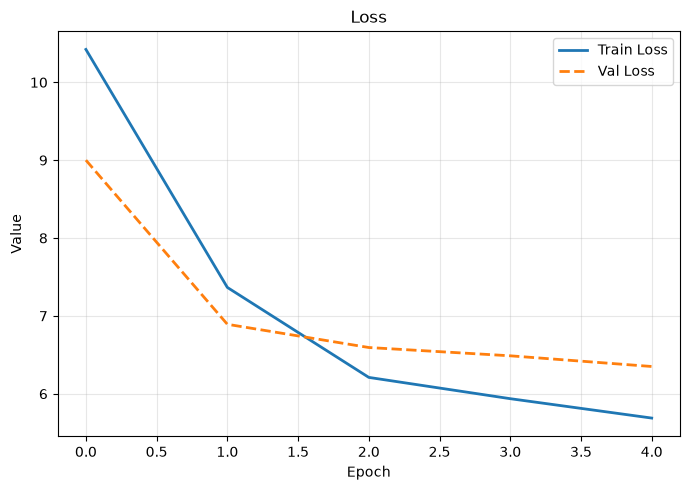

In [16]:
trainer.metrics.plot("train_loss","val_loss")

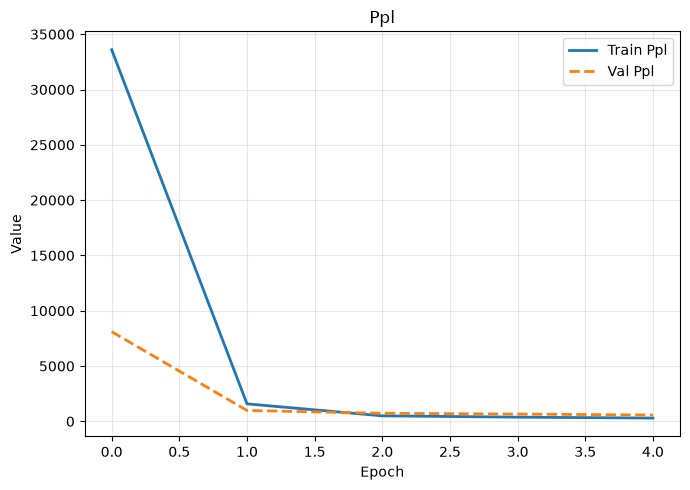

In [17]:
trainer.metrics.plot("train_ppl","val_ppl")

In [18]:
trainer.metrics.metrics

defaultdict(list,
            {'train_loss': [10.422240426143011,
              7.365508114298184,
              6.209954991936684,
              5.936543946464856,
              5.687673767407735],
             'train_acc': [0.024305555794853717,
              0.059244792287548385,
              0.07226562501940255,
              0.08572048616285126,
              0.11263020744081587],
             'train_ppl': [33598.62512257169,
              1580.5183064725086,
              497.6788512214721,
              378.6241204996178,
              295.20610322904537],
             'val_loss': [9.00010871887207,
              6.892033576965332,
              6.593786716461182,
              6.4873199462890625,
              6.349997043609619],
             'val_acc': [0.05416666716337204,
              0.04374999552965164,
              0.0520833320915699,
              0.06874999403953552,
              0.07708333432674408],
             'val_ppl': [8103.964933610405,
              984.401

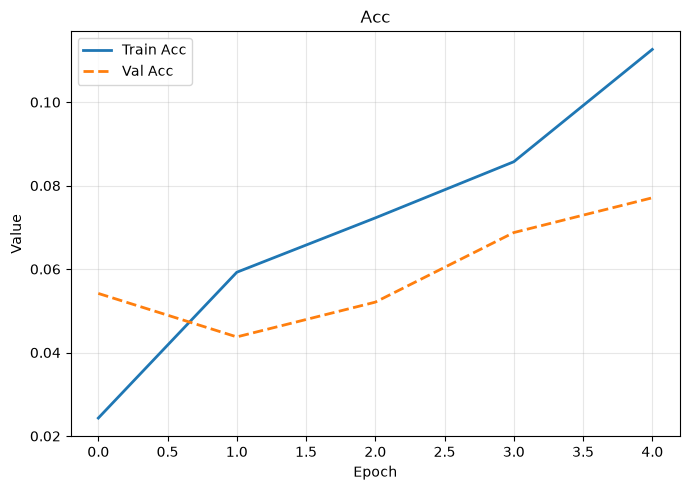

In [19]:
trainer.metrics.plot("train_acc","val_acc")